# Minneapolis Police Stop Analysis

---
## **Early Steps**
* The [MplsStops](https://rdrr.io/cran/carData/mand/MplsStops.html) dataset will be used
* The following python libraries will be used: pandas, matplotlib, statsmodels,

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

dfRaw = pd.read_csv("MplsStops.csv")
dfRaw.head()

,Unnamed: 0,idNum,date,problem,MDC,citationIssued,personSearch,vehicleSearch,preRace,race,gender,lat,long,policePrecinct,neighborhood
0,6823,17-000003,2017-01-01 00:00:42,suspicious,MDC,NaN,NO,NO,Unknown,Unknown,Unknown,44.966617,-93.246458,1,Cedar Riverside
1,6824,17-000007,2017-01-01 00:03:07,suspicious,MDC,NaN,NO,NO,Unknown,Unknown,Male,44.980450,-93.271340,1,Downtown West
2,6825,17-000073,2017-01-01 00:23:15,traffic,MDC,NaN,NO,NO,Unknown,White,Female,44.948350,-93.275380,5,Whittier
3,6826,17-000092,2017-01-01 00:33:48,suspicious,MDC,NaN,NO,NO,Unknown,East African,Male,44.948360,-93.281350,5,Whittier
4,6827,17-000098,2017-01-01 00:37:58,traffic,MDC,NaN,NO,NO,Unknown,White,Female,44.979078,-93.262076,1,Downtown West


---
### Summary of raw data:
We will be collecting the following:
1) A description of each column (data type/rows) using df.info()
2) A summary of the categorical data
3) A summary of the quantitative data using df.desribe()

In [6]:
columns = ["idNum","date", "problem", "MDC", 
           "citationIssued", "personSearch", 
           "vehicleSearch", "preRace", "race",
           "gender", "lat", "long", 
           "policePrecinct", "neighborhood"]
quantitative = ["idNum", "date", "lat", "long"]
categorical = [c for c in columns if c not in quantitative]
print("Column description and row counts:")
dfRaw.info()

print("\n-----------------------------")
print("Summary of categorical data:")
for column in categorical:
    print(f"___ {column} ___")
    print(dfRaw[column].value_counts(dropna=False), "\n")
print("\n-----------------------------")
print("Summary of quantitative data:")
dfRaw.describe()

Column description and row counts:
<class 'pandas.DataFrame'>
RangeIndex: 51920 entries, 0 to 51919
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      51920 non-null  int64  
 1   idNum           51920 non-null  str    
 2   date            51920 non-null  str    
 3   problem         51920 non-null  str    
 4   MDC             51920 non-null  str    
 5   citationIssued  19110 non-null  str    
 6   personSearch    43699 non-null  str    
 7   vehicleSearch   43699 non-null  str    
 8   preRace         43699 non-null  str    
 9   race            43699 non-null  str    
 10  gender          43638 non-null  str    
 11  lat             51920 non-null  float64
 12  long            51920 non-null  float64
 13  policePrecinct  51920 non-null  int64  
 14  neighborhood    51920 non-null  str    
dtypes: float64(2), int64(2), str(11)
memory usage: 5.9 MB

-----------------------------
Summary of c

,Unnamed: 0,lat,long,policePrecinct
count,51920.000000,51920.000000,51920.000000,51920.000000
mean,33860.553833,44.973966,-93.272800,3.256953
std,15587.470345,0.031021,0.023827,1.386659
min,6823.000000,44.890460,-93.329154,1.000000
25%,20378.750000,44.949260,-93.289833,2.000000
50%,33863.500000,44.975300,-93.276130,3.000000
75%,47387.250000,44.999135,-93.254971,4.000000
max,60838.000000,45.051240,-93.198869,5.000000


---
### Data Cleaning:

It is clear that many of the qualitative columns need cleaning due to NaN/"Unknown" values. Typically, rows with these values should be deemed invalid as they represent an error in the collection phase. There are, however, some exceptions that can be made for this analysis. 

* The first exception will be made for the "preRace" column as there are over 28,000 rows with "Unknown" values for it; this is plausible as cops might really not know the person's race before pulling them over in some cases. Even in the occasion they do know their races beforehand and fail to report, the remainder of the data shouldn't be invalidated.

* An exception will also be made towards the "gender" variable with "Unknown" rows since it is irrelevant in this exploration.

* Additionally, it can be noted that most of the rows in "citationIssued" are left as NaN, which is probably cause by police officers submitting this field as blank when not issuing citations. If all other invalid rows are removed, it is likely that the remaining NaN rows for this column mean that no citation was issued.


Overall, these are the categorical columns with some affected data:

* citationIssued
* personSearch
* vehicleSearch
* preRace
* race
* gender

As for the quantitative data, the values seem to be fine and contain no outliers.

The final problem is with how some of the data is represented.
1) The columns with YES/NO data are also treated as strings, to make their usage easier, they will be converted into booleans.
2) The "date" column is represented as a string, and month, date, as well as time are all in the same column. Ideally we transform this complex numerical column into three categorical columns: month (Jan-Dec), weekday(Mon-Sun), and time(Morning, Afternoon, Night) Most importantly, some date values contain time while others don't. This will be addressed by adding a fourth value to the time column: "Invalid".

In [7]:
df = dfRaw
print("Before Cleaning", len(df))

# First, clean rows with invalid data:
cols_to_drop_nulls = ["personSearch", "vehicleSearch", "preRace", "race", "gender"]
df = df.dropna(subset=cols_to_drop_nulls)
cols_to_drop_unknown = ["race"]
for column in cols_to_drop_unknown:
    df = df[df[column] != "Unknown"]

# Then clean boolean columns
cols_bool = ["citationIssued", "personSearch", "vehicleSearch"]
for column in cols_bool:
    df[column] = df[column].map({"YES": True, "NO": False})
# Convert NaN "citationIssued"rows into False
df['citationIssued'] = df['citationIssued'].fillna(False)
df['citationIssued'] = df['citationIssued'].astype(bool)

# Finally, handle date columns
# Start with month and weekday columns
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.month_name()
df["weekday"] = df["date"].dt.day_name()
# Handle time columns
bins = [0, 6, 14, 22, 24]
labels = ["Night", "Morning", "Afternoon", "Night"]
df["daytime"] = pd.cut(
    df["date"].dt.hour,
    bins=bins,
    labels=labels,
    ordered=False,
    include_lowest=True
)
df['has_time'] = (df['date'].dt.time != pd.Timestamp("00:00:00").time())
df = df.dropna(subset=["month"]) # There is one invalid date value

# Print information on new data
df.info()
for column in ["month", "weekday", "daytime"]:
    print(f"___ {column} ___")
    print(df[column].value_counts(dropna=False), "\n")

Before Cleaning 51920
<class 'pandas.DataFrame'>
Index: 34434 entries, 2 to 51918
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Unnamed: 0      34434 non-null  int64         
 1   idNum           34434 non-null  str           
 2   date            34434 non-null  datetime64[us]
 3   problem         34434 non-null  str           
 4   MDC             34434 non-null  str           
 5   citationIssued  34434 non-null  bool          
 6   personSearch    34434 non-null  bool          
 7   vehicleSearch   34434 non-null  bool          
 8   preRace         34434 non-null  str           
 9   race            34434 non-null  str           
 10  gender          34434 non-null  str           
 11  lat             34434 non-null  float64       
 12  long            34434 non-null  float64       
 13  policePrecinct  34434 non-null  int64         
 14  neighborhood    34434 non-null  str           
 

#### Thoughts on Data Cleaning
After cleaning data very liberally we are left with 34,434 entries: more than half of the raw data is still present. This amount of rows is also large enough to perform good statistical analyses.

## **Initial Analyses** 
### (Univariate)

To get some broad insights on the Minneapolis stops data, we will look at the following population proportions: Race and Problem.

A confidence interval for all the population proportions will be calculated. The Wilson score will be used since it is more accurate for values farther away from 0.5 (unlike the Wald score).

In [8]:
from statsmodels.stats.proportion import proportion_confint

total = len(df)

# Calculate population proportion CI for race
race_counts = df["race"].value_counts()

race_intervals = proportion_confint(race_counts, total, alpha=0.05, method='wilson')

race_df = pd.DataFrame({
    "race": race_counts.index,
    "count": race_counts.values,
    "proportion": (race_counts.values/total).round(3),
    "lower":race_intervals[0].round(3),
    "upper":race_intervals[1].round(3)
})
print(race_df)

# Calculate population proportion CI for problem (stop type)
problem_counts = df["problem"].value_counts()

problem_intervals = proportion_confint(problem_counts, total, alpha=0.05, method='wilson')

problem_df = pd.DataFrame({
    "problem": problem_counts.index,
    "count": problem_counts.values,
    "proportion": (problem_counts.values/total).round(3),
    "lower":problem_intervals[0].round(3),
    "upper":problem_intervals[1].round(3)
})
print("\n", problem_df)

                            race  count  proportion  lower  upper
race                                                             
Black                      Black  15204       0.442  0.436  0.447
White                      White  11690       0.339  0.335  0.345
East African        East African   2187       0.064  0.061  0.066
Latino                    Latino   1857       0.054  0.052  0.056
Native American  Native American   1513       0.044  0.042  0.046
Other                      Other   1338       0.039  0.037  0.041
Asian                      Asian    645       0.019  0.017  0.020

                problem  count  proportion  lower  upper
problem                                                
traffic        traffic  22444       0.652  0.647  0.657
suspicious  suspicious  11990       0.348  0.343  0.353


---
### Plotting CIs:
#### Race:

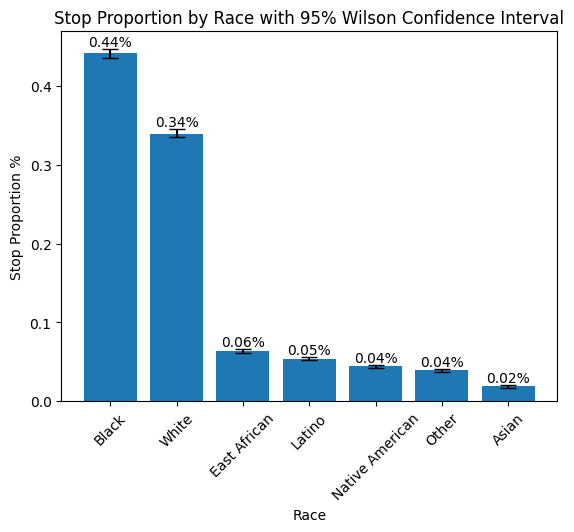

In [15]:
import matplotlib.pyplot as plt

# Calculate distance between CI bounds and proportion:
lower_error = race_df["proportion"] - race_df["lower"]
upper_error = race_df["upper"] - race_df["proportion"]
errors = [lower_error, upper_error]

# Configure Graph:
plt.figure()
bars = plt.bar(race_df['race'], race_df['proportion'], yerr=errors, capsize=6)

plt.title('Stop Proportion by Race with 95% Wilson Confidence Interval')
plt.ylabel("Stop Proportion %")
plt.xlabel("Race")
plt.bar_label(bars, fmt='%.2f%%')
plt.xticks(rotation=45)

# Plot
plt.show()

####

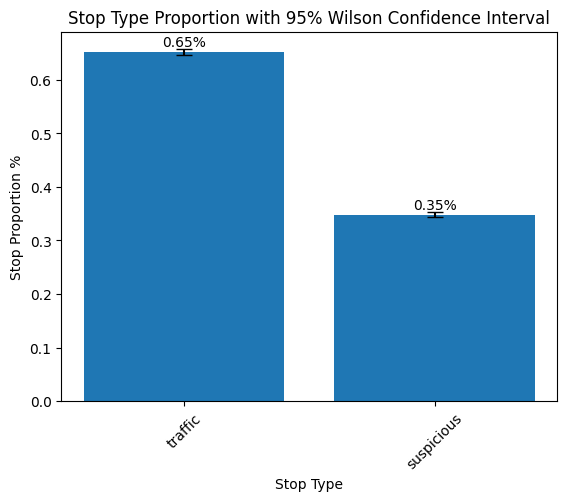

In [14]:
import matplotlib.pyplot as plt

# Calculate distance between CI bounds and proportion:
lower_error = problem_df["proportion"] - problem_df["lower"]
upper_error = problem_df["upper"] - problem_df["proportion"]
errors = [lower_error, upper_error]

# Configure Graph:
plt.figure()
bars = plt.bar(problem_df['problem'], problem_df['proportion'], yerr=errors, capsize=6)

plt.title('Stop Type Proportion with 95% Wilson Confidence Interval')
plt.ylabel("Stop Proportion %")
plt.xlabel("Stop Type")
plt.bar_label(bars, fmt='%.2f%%')
plt.xticks(rotation=45)


# Plot
plt.show()

#### Conclusion to Univariate Analyses
This analysis reveals a that there is a strong difference in number of stops by race. With a 95% confidence level, we can see that the proportion of stops for Black people [43.6%-44.7%] is significantly higher than that of White people [33.5%-34.5%], which in turn is significantly higher than that of all other ethnicities combined (~22%). 

[Minneapolis demographic data from 2021](https://en.wikipedia.org/wiki/Demographics_of_Minneapolis) show that White people represent over 60% of the city's population, while Black people represent only 16%. 

Pairing these two observations indicate that black people are significantly overrepresented in police stops. Establishing this, the next phase of this analysis will seek to determine if a similar disparity exists in how these individuals are treated before and during the stop.

With a 95% confidence level, it can also be stated that traffic violations correspond to the majority of traffic stops [64.7%-65.7%], but stops attributed to suspicious behavior [34.3%-35.3%] still compose a sizeable portion of the stops. This some important context to some of the following explorations.

## **Race and Stop Type**
#### (Bivariate and Chi-Squared)

---
### What we are looking for:
With the previous analysis, we spotted that black Minneapolis residents are stopped disproportionally more than other races. The natural follow-up to that observation is to question why it happens. To do so, we will analyze the relationship between stop type (traffic or suspicion) with race. While stops relating to traffic violation are mostly caused by the driver, a stop due to suspicion might indicate a form of discrimination on the behalf of the police officers.

### Bivariate Analysis
We will begin with a confidence interval comparing race and stop type

In [12]:
results = []

# Get 95% confidence interval with Wilson score of suspicion rate for each race
for race in df["race"].unique():
    subset = df[df["race"] == race]
    stop_count = len(subset)
    suspicious_count = len(subset[subset["problem"] == "suspicious"])

    lower, upper = proportion_confint(suspicious_count, stop_count, alpha=0.05, method="wilson")

    results.append({
        "race": race,
        "suspicion_rate": suspicious_count / stop_count,
        "lower": lower,
        "upper": upper
    })

race_suspicion_df = pd.DataFrame(results).sort_values("suspicion_rate", ascending=False)
print(race_suspicion_df)

              race  suspicion_rate     lower     upper
5  Native American        0.775942  0.754248  0.796238
3            Other        0.393871  0.368030  0.420320
2            Black        0.358327  0.350741  0.365984
0            White        0.301967  0.293711  0.310354
1     East African        0.293553  0.274842  0.312987
6           Latino        0.285407  0.265326  0.306373
4            Asian        0.215504  0.185506  0.248871


#### Visualizing

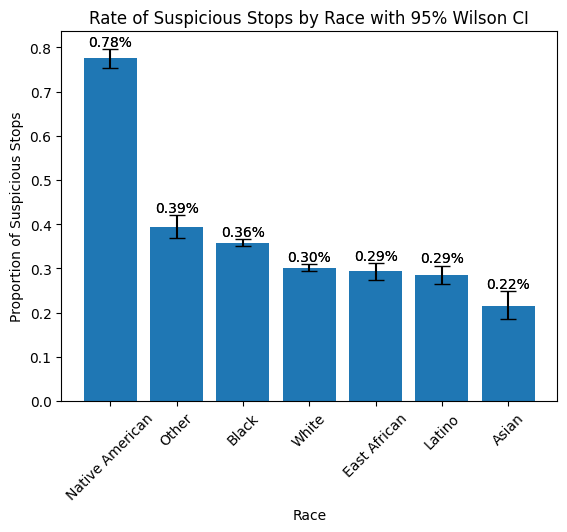

In [18]:
plt.figure()

lower_error = race_suspicion_df["suspicion_rate"] - race_suspicion_df["lower"]
upper_error = race_suspicion_df["upper"] - race_suspicion_df["suspicion_rate"]
errors = [lower_error, upper_error]

bars = plt.bar(race_suspicion_df["race"], race_suspicion_df["suspicion_rate"], yerr=errors, capsize=6)
plt.bar_label(bars, fmt='%.2f%%')

plt.title("Rate of Suspicious Stops by Race with 95% Wilson CI")
plt.ylabel("Proportion of Suspicious Stops")
plt.xlabel("Race")
plt.xticks(rotation=45)
plt.bar_label(bars, fmt='%.2f%%')
plt.show()

#### Findings

While Native Americans face a radically high rate of suspicious stops (~78%), they represent a small volume of total police stops, even when adjusting to their demographic representation. This exploration will prioritize the Black population since the univariate analysis showed that they are grossly overrepresented whe it comes to police stops.

In all, with a 95% confidence level, it can be concluded that the black population's suspicion stop confidence interval [35.1%-36.5%] is larger than that of White [29.3%-31.0%], East African [27.5%-31.3%], Latino [26.5%-30.6%], and Asian populations [18.6%-24.9%]. Paired with the extremely high Native American suspicion proportion, we have evidence that suggests that there is a disparity in stop types caused by race. To further analyze this disparity, we will perform a Chi-Squared test for Independence.

### Chi-Squared Test

A Chi-Squared Test for Independence will be performed to formally evaluate whether race and stop reason are dependent or independent.

Additionally, this test will focus only on the white and black population for the following two reasons:
1) The two populations are by far the most stopped, they combine for 78% of the total volume.
2) Certain populations - namely Native American and Asian - are radically far from the population mean (>10% distance).

* H<sub>o</sub>: The probability of a stop based off suspicion is independent of race (Black and White).
* H<sub>a</sub>: The probability of a stop based off suspicion is dependent on race.


In [38]:
import statsmodels.api as sm

# Filter for only black and white:
df_bw = df[df["race"].isin(["Black", "White"])]
    
# Get table of frequencies
chi_table_stoptype = pd.crosstab(df_bw["race"], df_bw["problem"])

# Perform Chi-squared test
chi_table_stoptype = sm.stats.Table(chi_table_stoptype)
result = chi_table_stoptype.test_nominal_association()

print("Chi-Squared Test for Independence Results")
print(f"Statistic: {result.statistic:.2f}")
print(f"P-Value: {result.pvalue:.4f}")

Chi-Squared Test for Independence Results
Statistic: 94.39
P-Value: 0.0000


#### Visualizing

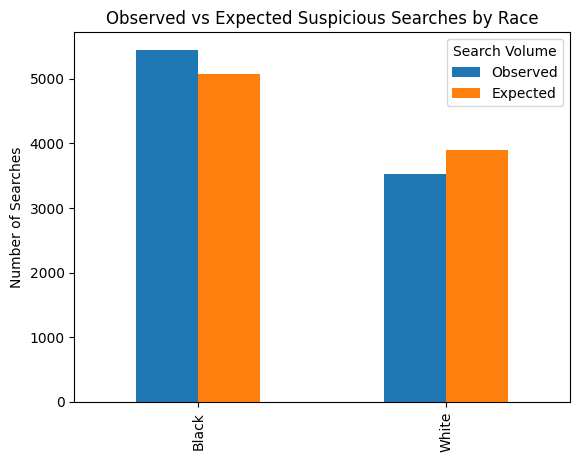

In [39]:
# Get observed and expected values and o
observed = chi_table_stoptype.table_orig
obs_df = observed.reset_index().melt(id_vars="race", value_name="count")
obs_df["type"] = "Observed"

expected = chi_table_stoptype.fittedvalues
exp_df = expected.reset_index().melt(id_vars="race", value_name="count")
exp_df["type"] = "Expected"

plot_data = pd.DataFrame({
    "Observed": [observed.loc["Black", "suspicious"], observed.loc["White", "suspicious"]],
    "Expected": [expected.loc["Black", "suspicious"], expected.loc["White", "suspicious"]]
}, index=["Black", "White"])

ax = plot_data.plot(kind="bar")

plt.title("Observed vs Expected Suspicious Searches by Race")
plt.ylabel("Number of Searches")
plt.legend(title="Search Volume")
plt.show()

#### Findings

Given that the following values from the analysis:
* degrees of freedom = 1
* test statistic = 94.39

We can, at the 0.5% significance level, reject the null hypothesis that stop type and race are independent. Specifically, the analysis indicates that the Black population faces proportionally more stop due to suspicions than they should if the two variables were independent. This suggests that the threshold for stops is lower for black individuals compared to whites.

## **Race and Person Searches**
#### (Bivariate and Chi-Squared

### What we are looking for:

From the previous analysis, we learned that there exists discrimination at the initialization of police stops. It is important to acknowledge that the stop is only the beginning of the interaction, thus, we seek to investigate if there exists discrimination in otehr portions of the interaction. This will be done by examining the relationship between race and person searches. This is because a person search is a physical and intrusive action: it represents escalation beyond a routine stop.

### Bivariate Analysis
We will begin with a confidence interval comparing race and person searches

In [40]:
results = []

# Get 95% confidence interval with Wilson score of person search for each race
for race in df["race"].unique():
    subset = df[df["race"] == race]
    stop_count = len(subset)
    searched_count = len(subset[subset["personSearch"] == True])

    lower, upper = proportion_confint(searched_count, stop_count, alpha=0.05, method="wilson")

    results.append({
        "race": race,
        "search_rate": searched_count / stop_count,
        "lower": lower,
        "upper": upper
    })

race_search_df = pd.DataFrame(results).sort_values("search_rate", ascending=False)
print(race_search_df)

              race  search_rate     lower     upper
5  Native American     0.306675  0.283955  0.330375
2            Black     0.203565  0.197240  0.210040
3            Other     0.127055  0.110272  0.145974
6           Latino     0.119009  0.105063  0.134529
4            Asian     0.096124  0.075709  0.121321
0            White     0.081608  0.076782  0.086709
1     East African     0.076818  0.066384  0.088735


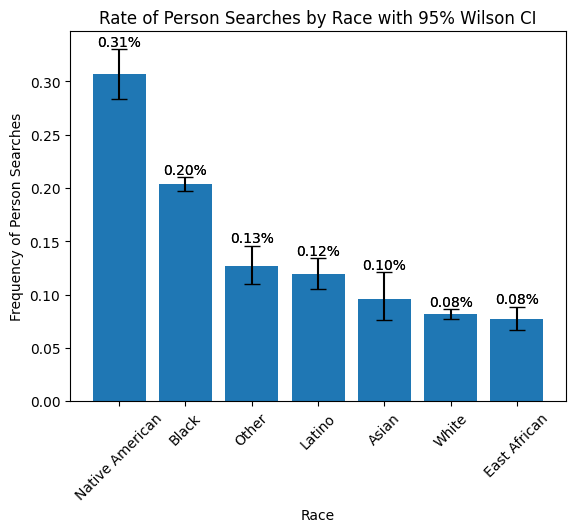

In [41]:
plt.figure()

lower_error = race_search_df["search_rate"] - race_search_df["lower"]
upper_error = race_search_df["upper"] - race_search_df["search_rate"]
errors = [lower_error, upper_error]

bars = plt.bar(race_search_df["race"], race_search_df["search_rate"], yerr=errors, capsize=6)
plt.bar_label(bars, fmt='%.2f%%')

plt.title("Rate of Person Searches by Race with 95% Wilson CI")
plt.ylabel("Frequency of Person Searches")
plt.xlabel("Race")
plt.xticks(rotation=45)
plt.bar_label(bars, fmt='%.2f%%')
plt.show()

#### Findings

We can again observe extreme results for the Native American population, but they will again be discarded due to previous discussions. Perhaps another exploration of this data should seek to understand the results for this population.

In all, with a 95% confidence level, it can be concluded that the black population's person search frequency [19.7%-21.0%] is substantially larger than that of White [7.7%-8.7%], East African [6.6%-8.9%], Latino [10.5%-13.5%], and Asian populations [7.6%-12.1%]. Thus, we have evidence that suggests that there is a disparity in person search frequency caused by race. To further analyze this disparity, we will perform a Chi-Squared test for Independence.

### Chi-Squared Test

A Chi-Squared Test for Independence will be performed to formally evaluate whether race and stop reason are dependent or independent.

For similar reasons as the previous Chi-Squared Test, this test will exclude the Native American population. All other categories will be included in the test.

* H<sub>o</sub>: The probability of a person search is independent of race.
* H<sub>a</sub>: The probability of a person search is dependent on race.


In [51]:
# Filter Native American rows:
df_chi = df[df["race"] != "Native American"]
    
# Get table of frequencies
chi_table = pd.crosstab(df_chi["race"], df_chi["personSearch"])

# Perform Chi-squared test
chi_table = sm.stats.Table(chi_table)
result = chi_table.test_nominal_association()

print("Chi-Squared Test for Independence Results")
print(f"Statistic: {result.statistic:.2f}")
print(f"P-Value: {result.pvalue:.4f}")

print("\nResiduals:")
print(chi_table.standardized_resids)

Chi-Squared Test for Independence Results
Statistic: 921.63
P-Value: 0.0000

Residuals:
personSearch      False      True 
race                              
Asian          3.361880  -3.361880
Black        -29.728591  29.728591
East African   9.022165  -9.022165
Latino         2.904784  -2.904784
Other          1.584093  -1.584093
White         23.248142 -23.248142


#### Visualizing

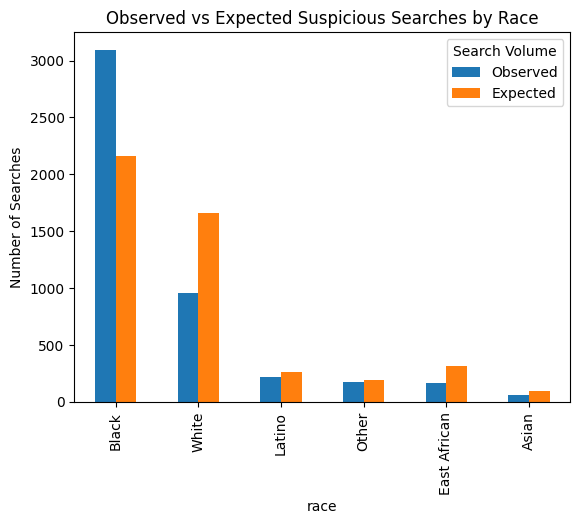

In [49]:
# Get observed and expected values and o
observed = chi_table.table_orig
obs_df = observed.reset_index().melt(id_vars="race", value_name="count")
obs_df["type"] = "Observed"

expected = chi_table.fittedvalues
exp_df = expected.reset_index().melt(id_vars="race", value_name="count")
exp_df["type"] = "Expected"

# Only include person searches in plot
plot_data = pd.DataFrame({
    "Observed": observed[True],
    "Expected": expected[True]
})
plot_data = plot_data.sort_values("Observed", ascending=False)

ax = plot_data.plot(kind="bar")

plt.title("Observed vs Expected Suspicious Searches by Race")
plt.ylabel("Number of Searches")
plt.legend(title="Search Volume")
plt.show()

#### Findings

Given that the following values from the analysis:
* degrees of freedom = 5
* test statistic = 921.63

We can, at the 0.5% significance level, reject the null hypothesis that the probability of a person search is independent of race. Specifically, the analysis indicates that the Black population faces disproportionally more person searches than they should if the two variables were independent. This suggests that officers are more likely to escalate interactions with the Black population: this could potentially be caused by discrimination.

## **Hit Rate Analysis**
#### (Logistic Regression)

## **Mapping**